**El propósito global de este tercer cuaderno es construir, entrenar y evaluar el motor del modelo de predicción de riesgo de incedio: una red neuronal profunda de arquitectura Late Fusion. Este modelo aprende a correlacionar simultáneamente la orografía y el estrés hídrico forestal de las imágenes satelitales con las condiciones meteorológicas tabulares para predecir el índice de riesgo de incendio, exportando el archivo definitivo que alimentará el flujo automatizado del proyecto final.**

1. LIBRERÍAS, PREPARACIÓN Y ANÁLISIS DE LA VARIABLE OBJETIVO

Importo las librerías de Deep Learning (TensorFlow/Keras) y visualización. Cargo el CSV generado en el Cuaderno 2 y dibujo un histograma del Ground Truth (Riesgo_Total) para verificar su distribución estadística y confirmar que la red neuronal tendrá ejemplos suficientes de todos los niveles de riesgo sin sesgos graves.

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1sUyLui8WwdFkKDFzxrDl5inOcJ3DZ3rG
From (redirected): https://drive.google.com/uc?id=1sUyLui8WwdFkKDFzxrDl5inOcJ3DZ3rG&confirm=t&uuid=bf0541ac-8a83-411e-8f87-efd38c2572c1
To: /content/datos_entrenamiento_tfm.zip
100% 750M/750M [00:02<00:00, 314MB/s]
replace /content/datos_entrenamiento_tfm/dataset_final_tfm.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
Cargando el dataset y analizando la variable objetivo...


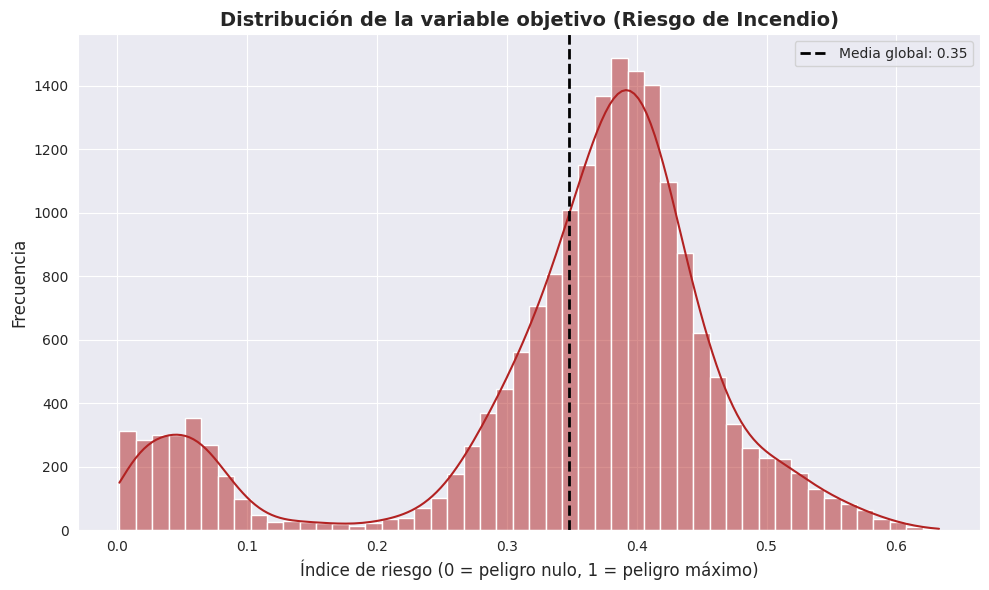

count    18476.000000
mean         0.348223
std          0.126825
min          0.001867
25%          0.322104
50%          0.379024
75%          0.419619
max          0.632780
Name: Riesgo_Total, dtype: float64


In [1]:
# Importaciones estándar y herramientas visuales
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Importaciones de Machine Learning y Deep Learning
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from keras import layers

# Configuro el estilo visual de las gráficas
sns.set_style('darkgrid')

# --- INGESTA DIRECTA PARA EL TRIBUNAL EVALUADOR ---
ID_DRIVE = "1sUyLui8WwdFkKDFzxrDl5inOcJ3DZ3rG"

!gdown --id {ID_DRIVE} -O datos_entrenamiento_tfm.zip
!unzip -q datos_entrenamiento_tfm.zip -d /content/datos_entrenamiento_tfm/

# Configuración de rutas
RUTA_BASE = '/content/datos_entrenamiento_tfm'
RUTA_CSV_MAESTRO = os.path.join(RUTA_BASE, 'dataset_final_tfm.csv')
RUTA_TENSORES = os.path.join(RUTA_BASE, 'tensores_satelite')
RUTA_PAQUETE_IMG = os.path.join(RUTA_BASE, 'X_images_maestro.npy')

print("Cargando el dataset y analizando la variable objetivo...")
df = pd.read_csv(RUTA_CSV_MAESTRO)

# Renderizo la distribución estadística del Ground Truth
plt.figure(figsize=(10, 6))
sns.histplot(df['Riesgo_Total'], bins=50, kde=True, color='firebrick')

plt.title('Distribución de la variable objetivo (Riesgo de Incendio)', fontsize=14, fontweight='bold')
plt.xlabel('Índice de riesgo (0 = peligro nulo, 1 = peligro máximo)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.axvline(df['Riesgo_Total'].mean(), color='black', linestyle='dashed', linewidth=2,
            label=f"Media global: {df['Riesgo_Total'].mean():.2f}")
plt.legend()
plt.tight_layout()
plt.show()

print(df['Riesgo_Total'].describe())

2. GESTIÓN DE MEMORIA Y PARTICIÓN DE LOS DATOS

Compilo los miles de parches satelitales sueltos en un único gran tensor multidimensional en la memoria RAM, guardándolo como un paquete .npy para acelerar futuras ejecuciones. Aíslo las variables meteorológicas y divido todo el bloque de datos en dos conjuntos: 80% train y 20% test.

In [2]:
def compilar_matrices_satelitales(df: pd.DataFrame, ruta_tensores: str, ruta_paquete: str) -> np.ndarray:
    """
    Ensambla el tensor gigante de imágenes leyendo los parches individuales del disco,
    o carga directamente el paquete compilado si ya se generó previamente.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset que contiene la columna 'nombre_tensor' con los identificadores.
    ruta_tensores : str
        Directorio físico donde se alojan los recortes .npy individuales.
    ruta_paquete : str
        Ruta donde se guardará el array global.

    Returns
    -------
    np.ndarray
        Tensor masivo de dimensiones (N_muestras, 64, 64, 6) listo para la red neuronal.
    """
    if os.path.exists(ruta_paquete):
        return np.load(ruta_paquete)

    lista_imagenes = []
    for archivo in tqdm(df['nombre_tensor'], desc="ensamblando tensores espaciales"):
        lista_imagenes.append(np.load(os.path.join(ruta_tensores, archivo)))

    matriz_final = np.array(lista_imagenes, dtype=np.float32)
    np.save(ruta_paquete, matriz_final)

    return matriz_final

X_images = compilar_matrices_satelitales(df, RUTA_TENSORES, RUTA_PAQUETE_IMG)

X_tabular = df[['tmax', 'hrMedia', 'velmedia']].values.astype(np.float32)
y = df['Riesgo_Total'].values.astype(np.float32)

# Partición de datos para validación cruzada (80% train, 20% test).
X_img_train, X_img_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
    X_images, X_tabular, y, test_size=0.2, random_state=42)

3. DISEÑO DE LA ARQUITECTURA LATE FUSION

Construyo las dos ramas del modelo. La primera es una red convolucional (CNN) que extrae patrones visuales del terreno y el bosque. La segunda es un perceptrón multicapa para los datos climáticos. Concateno ambas ramas para que la IA tome una decisión unificada, añado capas Dropout para evitar la memorización, y configuro la función de pérdida con el Error Cuadrático Medio (MSE).

In [3]:
def construir_red_late_fusion(shape_img: tuple, shape_tab: tuple) -> keras.Model:
    """
    Diseña una red neuronal de doble entrada que procesa visión artificial y
    datos tabulares en paralelo, fusionando sus inferencias en la capa de salida.

    Parameters
    ----------
    shape_img : tuple
        Dimensiones del tensor de entrada de imágenes (alto, ancho, canales).
    shape_tab : tuple
        Dimensiones del vector de entrada tabular (variables meteorológicas).

    Returns
    -------
    keras.Model
        Modelo compilado con optimizador Adam y función de pérdida Mean Squared Error.
    """
    # Rama 1: Extracción de características espaciales y de biomasa (CNN)
    input_img = keras.Input(shape=shape_img, name='input_satelite')
    x = layers.Rescaling(1./10000.0)(input_img)
    x = layers.Conv2D(32, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Conv2D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Flatten()(x)
    cnn_out = layers.Dense(64, activation='relu')(x)

    # Rama 2: Procesamiento de datos meteorológicos (MLP)
    input_tab = keras.Input(shape=shape_tab, name='input_meteo')
    tab_out = layers.Dense(32, activation='relu')(input_tab)

    # Fusión de las ramas
    fusion = layers.Concatenate()([cnn_out, tab_out])
    f = layers.Dropout(0.3)(fusion)
    f = layers.Dense(64, activation='relu')(f)
    f = layers.Dropout(0.2)(f)

    # Salida
    outputs = layers.Dense(1, activation='linear', name='prediccion_riesgo')(f)

    modelo = keras.Model(inputs=[input_img, input_tab], outputs=outputs)
    modelo.compile(optimizer='adam', loss='mse', metrics=['mae'])

    return modelo

modelo_riesgo = construir_red_late_fusion(shape_img=(64, 64, 6), shape_tab=(3,))
modelo_riesgo.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_satelite      │ (None, 64, 64, 6) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 64, 64, 6) │          0 │ input_satelite[0… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      1,760 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16384)     │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_meteo         │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │  1,048,640 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        128 │ input_meteo[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 96)        │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      6,208 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediccion_riesgo   │ (None, 1)         │         65 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,075,297 (4.10 MB)

 Trainable params: 1,075,297 (4.10 MB)

 Non-trainable params: 0 (0.00 B)

4. ENTRENAMIENTO, COMPROBACIÓN Y EMPAQUETADO.

Lanzo el entrenamiento de la red con un mecanismo de Early Stopping para detenerla de inmediato si detecta sobreajuste (overfitting). Evalúo su precisión sobre los datos de test calculando el MAE y grafico las inferencias frente a la realidad para comprobar su margen de error. Finalmente, guardo el modelo entrenado en formato .keras para que pueda cargarlo directamente en el entorno de producción futuro.

iniciando el entrenamiento del modelo...
Epoch 1/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0190 - mae: 0.0977 - val_loss: 0.0059 - val_mae: 0.0657
Epoch 2/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0068 - mae: 0.0621 - val_loss: 0.0052 - val_mae: 0.0596
Epoch 3/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0053 - mae: 0.0531 - val_loss: 0.0045 - val_mae: 0.0535
Epoch 4/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0045 - mae: 0.0475 - val_loss: 0.0052 - val_mae: 0.0623
Epoch 5/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0040 - mae: 0.0434 - val_loss: 0.0043 - val_mae: 0.0534
Epoch 6/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0037 - mae: 0.0408 - val_loss: 0.0034 - val_mae: 0.0439
Epoch 7/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0033 - mae: 0.0377 - val_loss: 0.0034 - val_mae: 0.0418
Epoch 8/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0031 - mae: 0.0361 - val_loss: 0.0028 - val_mae: 0.0352
Epoch 9/50
37

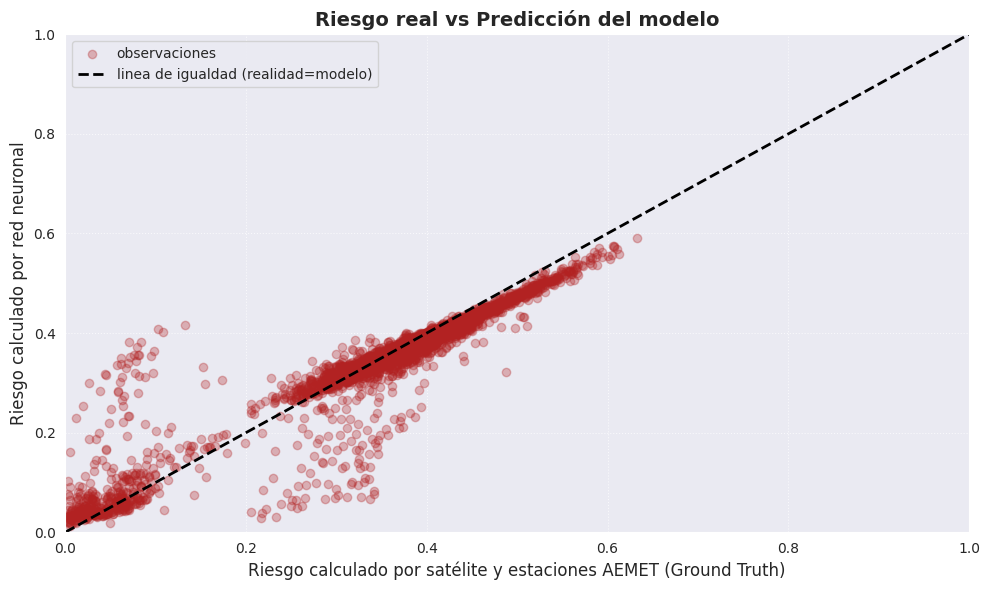

In [4]:
# Configuro el early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("iniciando el entrenamiento del modelo...")
historial = modelo_riesgo.fit(
    x=[X_img_train, X_tab_train],
    y=y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("\nEvaluando el rendimiento sobre los datos de Test...")
loss_test, mae_test = modelo_riesgo.evaluate(x=[X_img_test, X_tab_test], y=y_test, verbose=0)

print("\n   RESULTADOS DE LA PREDICCIÓN ")
print(f"Error Cuadrático Medio (MSE): {loss_test:.4f}")
print(f"Error Absoluto Medio (MAE): {mae_test:.4f}")
print(f"La red se equivoca un {(mae_test * 100):.2f}% al predecir el peligro real.")

y_pred = modelo_riesgo.predict([X_img_test, X_tab_test], verbose=0).flatten()

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='firebrick', label='observaciones')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=2, label='linea de igualdad (realidad=modelo)')

plt.title('Riesgo real vs Predicción del modelo', fontsize=14, fontweight='bold')
plt.xlabel('Riesgo calculado por satélite y estaciones AEMET (Ground Truth)', fontsize=12)
plt.ylabel('Riesgo calculado por red neuronal', fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


Exporto el modelo para su producción

In [5]:
from google.colab import drive
RUTA_DRIVE_MODELO = '/drive/MyDrive/TFM_Riesgo_Incendios_Canarias/modelo_late_fusion_definitivo.keras'
os.makedirs(os.path.dirname(RUTA_DRIVE_MODELO), exist_ok=True)
modelo_riesgo.save(RUTA_DRIVE_MODELO)